# N2 · Normalizing Flows
### *Explicit densities — road (a): exact likelihood via invertible transport*

> **Status:** 🟡 *in progress* — O2 ✅ · C2.1 ✅ · C2.2 ✅. **§3 built**: trained a 1D flow by the N1 MLE loop → KL 0.42 → **0.004**, val NLL → **1.75 ≈ H(p)** (floor gone) with **38 shared params**. Now at **C2.3 (predict)** + **C2.4 (sampling / high-D)**. Strict gating **on**.

**The one new idea.** Take a simple base density we fully control and **warp it through a *learned invertible* map**. Because the map is invertible, we can read off the **exact** `log q(x)` — so we train with the *same* maximum-likelihood loop from N1. Only **slot 1 (the family)** changes; the objective does not.

$$\text{base } z\sim\mathcal N(0,1)\ \xrightarrow{\ x=T_\theta(z)\ \text{(invertible)}\ }\ x\sim q_\theta(x)$$

## §0 — Where we are, and what we now demand

Two notebooks pinned down a tension:

- **N1 (single Gaussian).** Trained by MLE $=$ minimizing forward $\mathrm{KL}(p\,\|\,q_\theta)$. It stalled at a **floor of $\mathrm{KL}=0.42$**. We proved this was the *family's* fault (slot 1 too rigid — one bump can't cover two), **not** the optimizer's. → **misspecification.**
- **N1b (KDE).** Let *the data be the model*; crushed the floor to $\mathrm{KL}=0.0018$. But it pays twice: it **stores every sample**, and it **dies in high dimensions** (curse of dimensionality — one kernel per point can't tile space).

So we want a family that is:

1. **Rich** — flexible enough to bend into two bumps *(the thing we keep from N1b)*;
2. **Exactly evaluable** — still hands us a closed-form `log q(x)`, so we reuse the cheap N1 MLE loop *(no new objective — this is what makes it "road (a)")*;
3. **Compactly parameterized** — a *small, shared* parameter set, not one knob per datum *(the thing we fix from N1b, so it survives in high-D)*.

**The idea — *transport*.** Start from a base density $p_Z$ we own completely — the standard normal: we can *sample* it and *evaluate* it trivially. Then **push it through an invertible map** $x = T_\theta(z)$. The result is a new density $q_\theta(x)$, the *pushforward*. Make $T_\theta$ flexible (a little neural-ish warp) and $q_\theta$ can take almost any shape — yet because $T_\theta$ is **invertible**, $q_\theta(x)$ stays **exactly computable**. That last clause is the whole trick, and O2 is about *why it works*.

In [2]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import jax, jax.numpy as jnp
from jax import random
import optax
import matplotlib.pyplot as plt
from toylab import two_bumps
from toylab.metrics import kl_grid, wasserstein1

key = random.PRNGKey(0)
k_tr, k_va = random.split(key)
N = 2000
data = two_bumps.sample(k_tr, N)      # the bag of samples — ALL the model is allowed to see
val  = two_bumps.sample(k_va, N)      # held-out, for honest scoring (the N1b lesson)
grid   = jnp.linspace(-8, 8, 4000)
p_grid = jnp.exp(two_bumps.log_prob(grid))   # we secretly know p — used ONLY to grade

LOG2PI = jnp.log(2 * jnp.pi)
def log_base(z):                      # base density p_Z = standard normal (sample-able AND evaluable)
    return -0.5 * LOG2PI - 0.5 * z**2

print(f"{N} samples from two_bumps.  Reminder from N1: H(p) = 1.749 nats = the NLL floor a *perfect* model hits.")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


2000 samples from two_bumps.  Reminder from N1: H(p) = 1.749 nats = the NLL floor a *perfect* model hits.


## 🤔 O2 — opening objectives
*(answer in chat; we don't build until these hold)*

**O2.1 — Connect.** N1's single Gaussian stalled at forward $\mathrm{KL}=0.42$ (we blamed the *family*, slot 1 — not the optimizer). N1b's KDE crushed the floor but couldn't scale. State, in a phrase each, the **three properties** we now demand of a family — and say explicitly **which N1b strength we want to keep** and **which N1b weakness we want to fix**.

**O2.2 — Predict / spot-the-bug.** We set $x = T(z)$ with $z\sim\mathcal N(0,1)$ and $T$ invertible. A learner claims:
> *"Then the density of $x$ is just $q(x) = \mathcal N\!\big(T^{-1}(x);\,0,1\big)$ — plug the pre-image back into the base."*

**This is wrong.** What did they forget, and — intuitively — *why must it be there*?
*Hint: picture a fixed lump of probability mass sitting near $x$. What happens to its **height** (density) if $T$ **stretches** the line there, versus **squeezes** it? Total mass is conserved.*

*Your answer (O2):*

- **O2.1 — from N1b we liked that we could find a sweetspot between variance/bias errors in 1D for KDE but that didnt scale well for increasing dimensions.  
- **O2.2 —** they forgot the jacobain of dT/dz cause if T expands the domain the q(x) has to keep their total mass to 1 so has to divide by the increment

## §1 — Change of variables: the exact-density machinery

You just reinvented the mechanism in words; now we make it a formula.

**Setup.** A base variable $z \sim p_Z$ (our standard normal), and an **invertible, differentiable** map $x = T(z)$, with inverse $z = T^{-1}(x)$. We want the density $q_X(x)$ of the transformed variable.

**The one law we start from — conservation of probability mass.** The map can't create or destroy probability: the chunk of mass sitting in $[x,\,x+dx]$ is exactly the mass that was in its pre-image $[z,\,z+dz]$. So

$$ q_X(x)\,|dx| \;=\; p_Z(z)\,|dz|, \qquad z = T^{-1}(x). $$

The $|\cdot|$ keep lengths positive even if $T$ flips orientation. Everything else is algebra — which is C2.1.

## 🤔 C2.1 — Derive the change-of-variables formula  *(the gate)*

Starting from $\;q_X(x)\,|dx| = p_Z(z)\,|dz|\;$ with $z = T^{-1}(x)$:

**(a) Density form.** Solve for $q_X(x)$. Write it **two equivalent ways** — once with $\left|\dfrac{dz}{dx}\right|$, and once with $\dfrac{1}{\left|\,dx/dz\,\right|}$. Make sure you see why they're the same object.

**(b) Log form** — what we actually hand the optimizer. Take $\log$:
$$ \log q_X(x) \;=\; \underbrace{\log p_Z\!\big(T^{-1}(x)\big)}_{\text{base term}} \;+\; \underbrace{\;?\;}_{\text{correction}} $$
Fill in the correction term (a log-derivative). *This is the **log-det-Jacobian**: in 1D just a log-derivative; in $\ge 2$D it becomes $\log|\det J|$ — the source of all flow architecture.*

**(c) Hand-compute sanity check.** Take the affine map $x = T(z) = \sigma z + \mu$ with $\sigma > 0$. Find $T^{-1}(x)$ and the correction term, plug into your part (b), simplify. **What familiar density falls out?** *(Predict before you simplify — it should connect to a notebook you've already finished.)*

*Your answer (C2.1):*

- **(a)** q(x) = p_z(T-1(x)) dz/dx = p_z(T-1(x)) 1/ (dx/dz) and dz/dx = dT-1/dx  or dx/dz = dT/dz?
- **(b)** the correciton is -log(dx/dz) or +log(dz/dx) for 1D that would be log 
- **(c)** log qx = log N(x-u/sigma) -logsigma 

## §2 — One affine map is just N1 again. So where does a flow get its power?

Look hard at what C2.1(c) just proved: the simplest invertible map, the **affine** $x=\sigma z+\mu$, pushes the standard normal to **exactly** $\mathcal N(\mu,\sigma^2)$ — *N1's single-Gaussian family*. So an affine flow inherits N1's wall: forward $\mathrm{KL}=0.42$, the misspecification floor. One bump in, one bump out.

Why so weak? Re-read the log-density,
$$\log q(x) \;=\; \log p_Z\big(T^{-1}(x)\big)\;-\;\log\big|T'(T^{-1}(x))\big|.$$
For the affine map $T'(z)=\sigma$ is a **constant** — so the correction term $-\log|T'|$ is the same everywhere. It can only *rescale* the base bump uniformly; it can never **carve** one bump into two. The reshaping power lives entirely in letting the slope $T'(z)$ **vary with $z$**: where $T$ is *flat* (small slope) probability mass piles up into a **peak**; where $T$ is *steep* (large slope) it thins into a **valley**.

That gives two ways to build a rich-but-still-exact family — and real flows use both:
1. **Nonlinearity** — make $T$ a flexible *monotonic nonlinear* map (this is the 1D lever).
2. **Depth** — *compose* many simple invertible maps $T=T_L\circ\cdots\circ T_1$; log-dets just **add up**, so $\log q$ stays exact.

Before we code one, prove to yourself that a single *monotonic* map is already enough to make a unimodal base bimodal — that's the whole bet of N2.

## 🤔 C2.2 — Why an affine flow is stuck, and what escapes it  *(the gate)*

**(a) Break-it / Connect.** We showed an affine flow reproduces $\mathcal N(\mu,\sigma^2)$ — N1's family, KL floor $0.42$. Point to the *exact term* in $\log q(x)=\log p_Z(T^{-1}(x))-\log|T'(T^{-1}(x))|$ that went **dead** (couldn't reshape) for the affine map, say **why** it went dead, and state what that term must do instead to carve **two** bumps.

**(b) Predict.** The base is unimodal $\mathcal N(0,1)$. Using a **single** map $T$ that is **monotonically increasing** (so invertible — no composition, no orientation flips): *can the pushforward $q(x)$ be **bimodal**?* Answer yes/no, then justify in one sentence via the log-det intuition — i.e. what must $T'(z)$ do over the two regions that should become peaks versus the gap between them?

**(c) Derive — the one constraint we can never drop.** Invertibility is non-negotiable. In 1D, write the single condition on $T'(z)$ that guarantees $T$ is invertible **everywhere**. Then explain what happens to the density and to the log-det term $-\log|T'(z)|$ at a point where $T'(z)=0$ — and connect that to *why* every flow architecture is built from **strictly monotone** building blocks.

*Your answer (C2.2):*

- **(a)** 
- **(b)** 
- **(c)** 

## §3 — Build the flow: same MLE loop, richer family (slot 1)

C2.2 told us *what* we need (a position-varying slope, strictly monotone). Now a design choice that makes training cheap.

**Which direction do we parameterize?** The change-of-variables needs `T⁻¹` to evaluate `log q(x)` on data. Inverting a learned map every step would be painful — so we **parameterize the inverse directly**. Define the *normalizing* map
$$f_\theta := T_\theta^{-1}:\ x \longmapsto z\quad(\text{data}\to\text{base}),$$
and read the density straight off it:
$$\log q_\theta(x) \;=\; \log p_Z\big(f_\theta(x)\big)\;+\;\log\big|f_\theta'(x)\big|.$$
(The sign flipped to **+** vs §1 because `f` *is* the inverse.) **Training touches only `f` and `f'(x)` — never an inverse.** Sampling will need `T=f⁻¹`; we defer that to C2.4.

**Where does `f'(x)` come from?** We don't hand-derive it — this is the notebook where `jax.grad` earns its keep: `f` is a scalar→scalar function, so `jax.grad(f)` *is* `f'(x)`. We then `vmap` it over the batch. (Autodiff through a parameterized transform — the seed of every flow.)

**The architecture — strictly monotone by construction** (so C2.2(c)'s `f'>0` can never be violated):
$$f_\theta(x)\;=\;\underbrace{e^{a}\,x + b}_{\text{positive-slope line}}\;+\;\sum_{k=1}^{K}\underbrace{\mathrm{softplus}(g_k)}_{\ge 0}\,\tanh\!\big(e^{u_k}x+v_k\big).$$
Every piece is non-decreasing in `x` (line slope `eᵃ>0`; each `tanh` has inner slope `e^{u_k}>0` and amplitude `≥0`), so `f` is strictly increasing and `f'(x)>0` everywhere — `log|f'|` is always finite. The `K` tanh "kinks" are exactly the position-varying slope C2.2(a) demanded: stack a few and `f` can be steep across the two bumps and flat in the gap.

Crucially this is **slot 1 only**: the objective (`nll`), the optimizer (Adam), the held-out scoring — all identical to N1. We swapped a 2-parameter Gaussian for a ~`3K+2`-parameter invertible warp.

## 🤔 C2.3 — Predict-then-run *(gate — commit before you run the next cell)*

You're about to train this flow with the **same** MLE loop that left N1's single Gaussian stuck at `val NLL ≈ 2.17`, `KL = 0.42`. Recall `H(p)=1.749` is the floor a *perfect* model hits.

**(a)** Predict where the flow lands: will `val NLL` sit nearer **2.17** (N1's wall) or **1.749** (the floor)? Will `KL(p‖q)` look more like **0.42** (N1) or **0.002** (KDE)? One sentence on *why* — what did adding the warp remove?

**(b)** The flow has `K=12` tanh terms → about **38** parameters; KDE stored **N=2000** kernels. Both can crush the KL floor. Which N1b weakness does the 38-vs-2000 gap fix, and why does that matter the moment we leave 1D?

**(c) Break-it (predict the failure).** Suppose we *dropped* the monotonicity guard — let an amplitude `softplus(g_k)` be replaced by a free `g_k` that training drives very negative, so somewhere `f'(x₀)=0`. What happens to `log q(x₀)` and to the loss at that point?

*Your answer (C2.3):*

- **(a)** I think KL will look closer to the KDE so the the 0 hitting NLL to the floor (entorpy of p) 
- **(b)** A KDE works awesome in 1D but does not scale will in dimensionality cause you need increasing number of samples as you increase dimensions to match neighbours close to you + as you increase dimension your max distance vs min distance neighbour get closer  
- **(c)** if you drop the monotonicity I think the function is just not invertable in the first place so you cannot perform the MLE ? then I am not sure about the f' being 0 probably tends to part of the loss being infty? cause is log(f')?

flow params  : 38   (KDE stored N=2000 kernels)
train NLL    : 1.7377
val   NLL    : 1.7522   (H(p)=1.749 = perfect-model floor)
KL(p||q)     : 0.00402  (N1 Gaussian 0.42 | KDE 0.0018)
W1(p,q)      : 0.03188
q integrates : 1.0000  (no normalizer written -- the log-det does it)


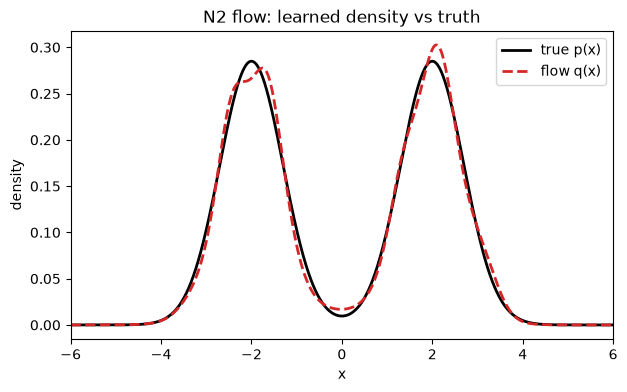

In [3]:
# --- N2 flow: parameterize the NORMALIZING map f: x -> z (strictly monotone) ---
from toylab.metrics import wasserstein1_cdf

K = 12
def init_params():
    return {"a": jnp.array(0.0), "b": jnp.array(0.0),
            "g": jnp.full((K,), -2.0),        # softplus(-2)=0.13 -> tiny warps; f starts ~ identity
            "u": jnp.zeros((K,)),             # exp(0)=1 inner slopes
            "v": jnp.linspace(-4.0, 4.0, K)}  # tanh kinks spread across the line

def softplus(x):
    return jnp.logaddexp(x, 0.0)

def f_scalar(x, p):                            # x -> z, strictly increasing by construction
    lin   = jnp.exp(p["a"]) * x + p["b"]                                       # slope exp(a) > 0
    bumps = jnp.sum(softplus(p["g"]) * jnp.tanh(jnp.exp(p["u"]) * x + p["v"]))  # + increasing terms
    return lin + bumps

dfdx_scalar = jax.grad(f_scalar, argnums=0)    # f'(x) for FREE via autodiff -- the N2 lesson

def log_q_scalar(x, p):                         # change of variables; +log|f'| because f = T^{-1}
    return log_base(f_scalar(x, p)) + jnp.log(dfdx_scalar(x, p))
log_q = jax.vmap(log_q_scalar, in_axes=(0, None))

def nll(p, xs):                                 # the SAME MLE objective as N1 -- only slot 1 changed
    return -jnp.mean(log_q(xs, p))

opt = optax.adam(3e-2)
@jax.jit
def step(p, st, xs):
    loss, g = jax.value_and_grad(nll)(p, xs)
    upd, st = opt.update(g, st, p)
    return optax.apply_updates(p, upd), st, loss

p = init_params(); st = opt.init(p)
n_params = sum(int(jnp.asarray(v).size) for v in jax.tree_util.tree_leaves(p))
for e in range(2000):
    p, st, loss = step(p, st, data)

# ---- score on held-out val + exact rulers (p is known ONLY for grading) ----
q_grid = jnp.exp(log_q(grid, p))
kl = float(kl_grid(p_grid, q_grid, grid)); w1 = float(wasserstein1_cdf(p_grid, q_grid, grid))
print(f"flow params  : {n_params}   (KDE stored N={N} kernels)")
print(f"train NLL    : {float(nll(p, data)):.4f}")
print(f"val   NLL    : {float(nll(p, val)):.4f}   (H(p)=1.749 = perfect-model floor)")
print(f"KL(p||q)     : {kl:.5f}  (N1 Gaussian 0.42 | KDE 0.0018)")
print(f"W1(p,q)      : {w1:.5f}")
print(f"q integrates : {float(jnp.trapezoid(q_grid, grid)):.4f}  (no normalizer written -- the log-det does it)")

# ---- eye test on the DENSITY (q(x) is exact; sampling needs the inverse -> C2.4) ----
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, p_grid, 'k',    lw=2, label='true p(x)')
ax.plot(grid, q_grid, 'C3--', lw=2, label='flow q(x)')
ax.set_xlim(-6, 6); ax.set_xlabel('x'); ax.set_ylabel('density')
ax.set_title('N2 flow: learned density vs truth'); ax.legend(); plt.show()


### §3 — what you should see (verified in `.venv`, seed 0, 2000 epochs)

| | N1 single Gaussian | **N2 flow** | N1b KDE |
|---|---|---|---|
| val NLL | ≈ 2.17 | **1.752** | ≈ 1.75 |
| KL(p‖q) | 0.42 *(floor)* | **0.004** | 0.0018 |
| parameters | 2 | **38** | 2000 kernels |
| `∫q` | 1 | **1.0000** | 1 |

Read it back against the three demands from O2.1:
1. **Rich** ✅ — a *unimodal* base became a *bimodal* `q` (the red curve traces both bumps): exactly C2.2(b), `f` steep across the bumps, flat in the gap.
2. **Exactly evaluable** ✅ — `val NLL` fell to `H(p)=1.749`; the **misspecification floor (0.42) is gone**, with the *same* MLE loop. And `∫q = 1.0000` though we never wrote a normalizer — the **log-det term self-normalizes** the density.
3. **Compactly parameterized** ✅ — **38 shared params**, not one-per-datum. KDE matched the fidelity but stored all 2000 samples; that per-point cost is what dies in high-D. The flow is the family that survives the jump out of 1D — which is the whole reason N2 exists.

The wall N1 hit was the *family's* fault, and we just changed the family — nothing else.

## 🤔 C2.4 — The catch we deferred, and the bridge to ≥2D *(gate)*

We trained using only `f: x→z` and `f'(x)`. But the eye test above plotted the **density**, not **samples** — on purpose.

**(a) Connect / spot-the-gap.** To *generate* a sample we need `x = T(z) = f⁻¹(z)` with `z∼𝒩(0,1)`. Explain why **training** never needed the inverse but **sampling** does — point to exactly which quantities each direction uses.

**(b) Derive an inverter.** `f` is strictly increasing and we can evaluate it cheaply at any `x`. Give a concrete algorithm to compute `f⁻¹(z)` to arbitrary precision **without a closed form**, and say which property from C2.2(c) is *precisely* what guarantees it converges to a unique answer.

**(c) Connect to high-D (previews N3).** In 1D the correction was a scalar `log|f'(x)|`. In `d`-dimensions it becomes `log|det J_f(x)|` for a `d×d` Jacobian — naively `O(d³)` per evaluation, which would kill flows. Name the structural property a Jacobian needs so its determinant is just the **product of the diagonal** (cheap), and the architectural idea that buys it. *(Hint: make coordinate `i`'s transform depend only on coordinates `<i`.)*

*Your answer (C2.4):*

- **(a)** yeah we need the inverse cause we sample 'z' and we need x so we gotta inverse T.  
- **(b)** without a closed form we can use netwons? is about finding roots no? hmm what is this algo that keeps finding + and - till you approach the 0?
- **(c)** yeah so a triangular jacobian would basically mean det is just the determinant being the multiplication of the diagonal